# Wiki Persona Attribute Extraction

Extract persona **attributes** (values + supporting descriptions/evidence) from the
MatrAIx wiki person profiles using a Qwen3 MoE model served with **vLLM**.

Pipeline:
1. Configure caches (all on `/n/netscratch/lu_lab/Lab/xiaominli`).
2. Download the gated wiki SQLite from HuggingFace (`MatrAIx2026/MatrAIx2026`).
3. Load & view the profiles.
4. Load the persona dimension schema (`persona/schema/dimensions.json`).
5. Build the extraction prompt (ported from `wiki_collab/collab_kit/solver.py`).
6. Load Qwen3.6-35B-A3B with vLLM (cache on netscratch).
7. Run an extraction demo on a few profiles and parse the JSON output.

> Kernel: use the **env05** conda env (`/n/home08/xiaominli/.conda/envs/env05`).
> Qwen3.6-35B-A3B is a new `qwen3_5_moe` (hybrid-attention, multimodal MoE)
> architecture that needs **vLLM >= 0.24.0** (which pins torch 2.11).

## 0. Configuration

Everything cache-heavy is pinned under `/n/netscratch/lu_lab/Lab/xiaominli` so nothing
lands on the home filesystem.

In [5]:
import os
from pathlib import Path

# --- Cache locations (must live on the netscratch filesystem) ---
NETSCRATCH = Path("/n/netscratch/lu_lab/Lab/xiaominli")
CACHE_ROOT = NETSCRATCH / "mycache"
HF_HOME = CACHE_ROOT / "hf_home"          # already set in ~/.bashrc; re-assert here
HF_HUB_CACHE = HF_HOME / "hub"            # model snapshots
HF_XET_CACHE = HF_HOME / "xet"            # Xet chunk cache (ignores HF_HOME by default!)
VLLM_DOWNLOAD_DIR = HF_HUB_CACHE          # let vLLM reuse the same hub cache

for p in (HF_HOME, HF_HUB_CACHE, HF_XET_CACHE):
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_HUB_CACHE"] = str(HF_HUB_CACHE)
os.environ["HF_XET_CACHE"] = str(HF_XET_CACHE)  # keep Xet cache off the home filesystem
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"  # faster large-file downloads
os.environ.setdefault("VLLM_WORKER_MULTIPROC_METHOD", "spawn")

# --- HF token (gated dataset). Set in ~/.bashrc as HF_TOKEN_matraix. ---
HF_TOKEN = os.environ.get("HF_TOKEN_matraix")
if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN_matraix not found in the environment.\n"
        "Start the kernel from a shell that sourced ~/.bashrc, or run:\n"
        "    os.environ['HF_TOKEN_matraix'] = '<token>'"
    )

# --- Dataset + schema locations ---
DATASET_REPO = "MatrAIx2026/MatrAIx2026"
SQLITE_REPO_PATH = "wiki/matraix_wiki_profiles_20260601_v1.sqlite"
REPO_ROOT = Path("/n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx")
DIMENSIONS_JSON = REPO_ROOT / "persona/schema/dimensions.json"

# Local data folder for the downloaded DB (git-ignored via data/.gitignore)
DATA_DIR = REPO_ROOT / "persona/human_extraction/data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- Model (edit if you want a different Qwen3 MoE checkpoint) ---
MODEL_ID = "Qwen/Qwen3.6-35B-A3B"

print("HF_HOME        :", os.environ["HF_HOME"])
print("HF_HUB_CACHE   :", os.environ["HF_HUB_CACHE"])
print("HF_XET_CACHE   :", os.environ["HF_XET_CACHE"])
print("DATA_DIR       :", DATA_DIR)
print("MODEL_ID       :", MODEL_ID)
print("dimensions.json:", DIMENSIONS_JSON, "exists=", DIMENSIONS_JSON.exists())


HF_HOME        : /n/netscratch/lu_lab/Lab/xiaominli/mycache/hf_home
HF_HUB_CACHE   : /n/netscratch/lu_lab/Lab/xiaominli/mycache/hf_home/hub
HF_XET_CACHE   : /n/netscratch/lu_lab/Lab/xiaominli/mycache/hf_home/xet
DATA_DIR       : /n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/human_extraction/data
MODEL_ID       : Qwen/Qwen3.6-35B-A3B
dimensions.json: /n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/schema/dimensions.json exists= True


## 1. Download the wiki SQLite from HuggingFace

The file is ~7.9 GB and lives in a **gated** dataset, so a token is required.
It is downloaded into the local `data/` folder next to this notebook
(`persona/human_extraction/data/`, git-ignored) rather than the shared hub cache.


In [6]:
from huggingface_hub import hf_hub_download

# Download straight into ./data (local_dir), not the shared hub blob cache.
sqlite_path = hf_hub_download(
    repo_id=DATASET_REPO,
    repo_type="dataset",
    filename=SQLITE_REPO_PATH,
    token=HF_TOKEN,
    local_dir=str(DATA_DIR),
)
print("Local SQLite:", sqlite_path)
print("Size (GB):", round(os.path.getsize(sqlite_path) / 1e9, 2))


Local SQLite: /n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/human_extraction/data/wiki/matraix_wiki_profiles_20260601_v1.sqlite
Size (GB): 7.86


## 2. Load & view the profiles

The DB has a single `profiles` table with columns: `global_idx, task_id, page_id,
qid, title, source_url, profile_text, input_sha256, source_file, source_row`.

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(f"file:{sqlite_path}?mode=ro", uri=True)

# Table overview
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn
)
print("Tables:", tables["name"].tolist())

n_rows = pd.read_sql_query("SELECT COUNT(*) AS n FROM profiles", conn)["n"][0]
print("Total profiles:", f"{n_rows:,}")

schema = pd.read_sql_query("PRAGMA table_info(profiles)", conn)
schema[["name", "type"]]

Tables: ['profiles']
Total profiles: 2,125,897


,name,type
0,global_idx,INTEGER
1,task_id,TEXT
2,page_id,INTEGER
3,qid,TEXT
4,title,TEXT
5,source_url,TEXT
6,profile_text,TEXT
7,input_sha256,TEXT
8,source_file,TEXT
9,source_row,INTEGER


In [4]:
# Peek at the first few profiles
sample = pd.read_sql_query(
    "SELECT global_idx, qid, title, source_url, profile_text "
    "FROM profiles ORDER BY global_idx LIMIT 5",
    conn,
)
pd.set_option("display.max_colwidth", 300)
sample

,global_idx,qid,title,source_url,profile_text
0,0,Q41746,Achilles,https://en.wikipedia.org/wiki/Achilles,"In Greek mythology, Achilles or Achilleus was a hero of the Trojan War who was known as being the greatest of all the Greek warriors. The central character in Homer's Iliad, he was the son of the Nereid Thetis and Peleus, king of Phthia and famous Argonaut. Achilles was raised in Phthia along wi..."
1,1,Q91,Abraham Lincoln,https://en.wikipedia.org/wiki/Abraham_Lincoln,"Abraham Lincoln (February 12, 1809 - April 15, 1865) was the 16th president of the United States, serving from 1861 until his assassination in 1865. He led the United States through the American Civil War, defeating the Confederacy and playing a major role in the abolition of slavery.\n\nBorn in..."
2,2,Q868,Aristotle,https://en.wikipedia.org/wiki/Aristotle,"Aristotle (; 384–322 BC) was an ancient Greek philosopher and polymath. His writings span the natural sciences, philosophy, linguistics, economics, politics, psychology, and the arts. As the founder of the Peripatetic school of philosophy in the Lyceum in Athens, he began the wider Aristotelian ..."
3,3,Q132524,Ayn Rand,https://en.wikipedia.org/wiki/Ayn_Rand,"Alice O'Connor (born Alisa Zinovyevna Rosenbaum;, 1905March 6, 1982), better known by her pen name Ayn Rand, was a Russian-American writer and philosopher. She is known for her fiction and for developing a philosophical system which she named Objectivism.\n\nBorn and educated in Russia, she move..."
4,4,Q313590,Alain Connes,https://en.wikipedia.org/wiki/Alain_Connes,"Alain Connes (; born 1 April 1947 ) is a French mathematician, known for his contributions to the study of operator algebras and noncommutative geometry. He was a professor at the,, Ohio State University and Vanderbilt University. He was awarded the Fields Medal in 1982.\n\nAlain Connes attended..."


In [5]:
# Full text of one example profile
row = sample.iloc[0]
print(f"[{row.global_idx}] {row.title} ({row.qid})")
print(row.source_url)
print("-" * 80)
print(row.profile_text)

[0] Achilles (Q41746)
https://en.wikipedia.org/wiki/Achilles
--------------------------------------------------------------------------------
In Greek mythology, Achilles or Achilleus was a hero of the Trojan War who was known as being the greatest of all the Greek warriors. The central character in Homer's Iliad, he was the son of the Nereid Thetis and Peleus, king of Phthia and famous Argonaut. Achilles was raised in Phthia along with his childhood companion Patroclus and received his education by the centaur Chiron. In the Iliad, he is presented as the commander of the mythical tribe of the Myrmidons.

Achilles's most notable feat during the Trojan War was the slaying of the Trojan prince Hector outside the gates of Troy. Although the death of Achilles is not presented in the Iliad, other sources concur that he was killed near the end of the Trojan War by Paris, who shot him with an arrow. Later legends (beginning with Statius's unfinished epic Achilleid, written in the first centur

## 3. Load the persona dimension schema

Each dimension = one persona attribute with a closed set of allowed values.
We group by `category` so prompts can be chunked (feeding all ~1.3k dimensions at
once is unwieldy).

In [6]:
import json
from collections import OrderedDict

with open(DIMENSIONS_JSON) as fh:
    schema_doc = json.load(fh)

DIMENSIONS = schema_doc["dimensions"]
print("schema:", schema_doc["name"])
print("total dimensions:", len(DIMENSIONS))

# Group dimensions by category (UI grouping only; schema stays flat)
by_category = OrderedDict()
for d in DIMENSIONS:
    by_category.setdefault(d.get("category", "Uncategorized"), []).append(d)

print("categories:", len(by_category))
for cat, dims in list(by_category.items())[:8]:
    print(f"  {cat:32s} {len(dims):3d} dims  e.g. {dims[0]['id']}")

schema: matrAIx Persona Dimension Space
total dimensions: 1290
categories: 43
  Demographic: Core                 25 dims  e.g. age_bracket
  Linguistic: Language              53 dims  e.g. primary_language
  Expertise: Domains               144 dims  e.g. domain
  Personality: Character            34 dims  e.g. domain_characteristics
  Learning: Academic                34 dims  e.g. highest_education
  Professional: Career               4 dims  e.g. research_output
  Professional: Industry            51 dims  e.g. company_size
  Demographic: Life Events          24 dims  e.g. life_stage


In [7]:
# Example dimension entry
DIMENSIONS[0]

{'id': 'age_bracket',
 'label': 'Age bracket',
 'category': 'Demographic: Core',
 'description': 'Life-age band of the persona.',
 'values': ['13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
 'index': 1,
 'phrase': 'aged {value}',
 'defaultValue': None}

## 3.5 Profile length distribution & long-profile handling

**Design decision: one source profile → one persona.** We never split a person's
profile into multiple chunks. The *only* chunking is over the **1,290 dimensions**
(the schema is too large for a single prompt, so it is split into 53 category
chunks). Every chunk carries the **same full profile** plus a different slice of
dimensions; the per-chunk field lists are merged back into a single persona.

For the rare very long profile we **truncate** it (character cap) rather than
split it — splitting would produce several partial personas for one person, which
we don't want. The cell below quantifies how long profiles actually are (in Qwen
tokens) so we can size the context window and confirm truncation touches almost
nothing.


n sampled : 20,000   mean=737  max=24,091
p50/p90/p95/p99/p99.9 tok : 430 / 1,606 / 2,386 / 5,100 / 14,386

fraction of FULL profiles exceeding a token limit:
  >  2,048 tok :  1,322  (6.61%)
  >  4,096 tok :    329  (1.65%)
  >  8,192 tok :     76  (0.38%)
  > 16,384 tok :     14  (0.07%)
  > 24,576 tok :      0  (0.00%)
  > 32,768 tok :      0  (0.00%)

prompt overflow (profile + ~5.5k dims + max_tokens) by context window:
  max_model_len=16384 (profile budget ~2,692 tok): full=805 (4.03%)  after 24000-char cap=805
  max_model_len=32768 (profile budget ~19,076 tok): full=4 (0.02%)  after 24000-char cap=0


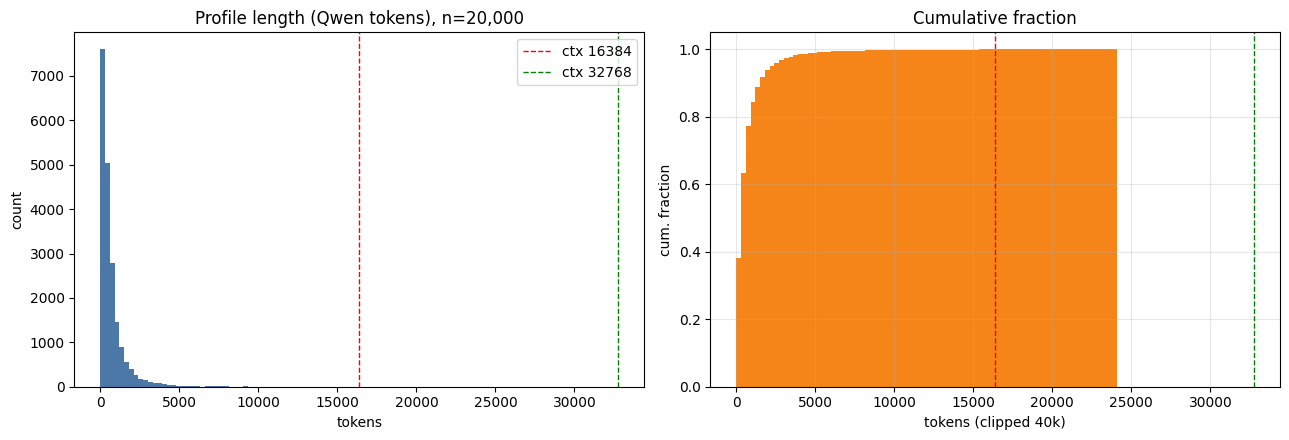

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# --- Config for long-profile handling ---
N_SAMPLE = 20000            # random profiles to sample for the distribution
MAX_PROFILE_CHARS = 24000   # truncate cap: profile is appended last in the prompt
MAX_TOKENS = 8192           # generation budget (per dimension chunk)
DIMS_OVERHEAD_TOK = 5500    # ~instructions + up to 50 dimension lines per chunk

# Tokenizer only (cheap) — no GPU / no vLLM needed to run this cell.
_tok = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=str(HF_HUB_CACHE))

rows = conn.execute(
    "SELECT profile_text FROM profiles ORDER BY RANDOM() LIMIT ?", (N_SAMPLE,)
).fetchall()
texts = [r[0] or "" for r in rows]

full_lens = np.array([len(x) for x in _tok(texts, add_special_tokens=False)["input_ids"]])
capped = [t[:MAX_PROFILE_CHARS] for t in texts]
capped_lens = np.array([len(x) for x in _tok(capped, add_special_tokens=False)["input_ids"]])

def pctl(a, p):
    return int(np.percentile(a, p))
print(f"n sampled : {len(full_lens):,}   mean={full_lens.mean():.0f}  max={full_lens.max():,}")
print(f"p50/p90/p95/p99/p99.9 tok : "
      f"{pctl(full_lens,50):,} / {pctl(full_lens,90):,} / {pctl(full_lens,95):,} / "
      f"{pctl(full_lens,99):,} / {pctl(full_lens,99.9):,}")

print("\nfraction of FULL profiles exceeding a token limit:")
for lim in (2048, 4096, 8192, 16384, 24576, 32768):
    n = int((full_lens > lim).sum())
    print(f"  > {lim:6,} tok : {n:6,}  ({100*n/len(full_lens):.2f}%)")

print("\nprompt overflow (profile + ~5.5k dims + max_tokens) by context window:")
for mml in (16384, 32768):
    budget = mml - MAX_TOKENS - DIMS_OVERHEAD_TOK
    n_full = int((full_lens > budget).sum())
    n_cap = int((capped_lens > budget).sum())
    print(f"  max_model_len={mml:5d} (profile budget ~{budget:,} tok): "
          f"full={n_full} ({100*n_full/len(full_lens):.2f}%)  "
          f"after {MAX_PROFILE_CHARS}-char cap={n_cap}")

# --- Histogram ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(full_lens, bins=80, color="#4C78A8")
ax[0].set(title=f"Profile length (Qwen tokens), n={len(full_lens):,}",
          xlabel="tokens", ylabel="count")
for lim, c in [(16384, "red"), (32768, "green")]:
    ax[0].axvline(lim, color=c, ls="--", lw=1, label=f"ctx {lim}")
ax[0].legend()
ax[1].hist(np.clip(full_lens, 0, 40000), bins=80, cumulative=True, density=True, color="#F58518")
ax[1].set(title="Cumulative fraction", xlabel="tokens (clipped 40k)", ylabel="cum. fraction")
for lim, c in [(16384, "red"), (32768, "green")]:
    ax[1].axvline(lim, color=c, ls="--", lw=1)
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Observed (20k random profiles):** median **414** tok, p95 **2.3k**, p99 **5.2k**,
p99.9 **13.2k**, max **~24.8k**; chars/token ≈ 3.97. Only **0.05%** exceed 16k tok
and **0%** exceed 32k tok.

**Why the naive 16k run crashed:** the profile is rarely the issue — overflow comes
from *profile + ~5.5k-token dimension chunk + 8k output*. With `max_model_len=16384`
that leaves only ~2.7k for the profile → **3.6%** overflow. With `max_model_len=32768`
the budget is ~19k → **0.03%**, and the 24k-char cap drives it to **0%**.

**Finalized handling:**
- `max_model_len = 32768`, `max_tokens = 8192`.
- Truncate `profile_text` to `MAX_PROFILE_CHARS = 24000` (≈ last-resort; affects
  ~0.03% of profiles). Truncate, **do not split** — one profile → one persona.
- (Optional) instead of truncating you could *drop* the handful of >32k-token
  profiles; at ~0.03% it makes no practical difference.
- Since the profile is tiny and the ~5.5k dimension block repeats across profiles,
  enabling vLLM **prefix caching** for the real run caches that shared prefix and
  cuts prefill substantially.


## 4. Build the extraction prompt

Extended from the dataset owner's default method in
`persona/curation/existing_data/wiki_collab/collab_kit/solver.py` (`build_prompt`).

For each dimension (attribute) the model returns one structured object with:
`field_id`, `value` (an allowed value verbatim or `null`), `confidence` (0..1),
`evidence` (a short verbatim quote from the profile for grounding),
`description` (a **1–2 sentence detailed description of the person** for this
attribute — e.g. attribute `python_proficiency` = `high`, description: "Has
authored over two million lines of code…"), and `assignment_type`
(`direct | structured_claim | summary_inference | unsupported`).


In [ ]:
def build_prompt(profile_text: str, dimensions: list[dict]) -> str:
    """Wikipedia-profile extraction prompt (extended from solver.build_prompt).

    Per dimension the model returns a structured object with the chosen value,
    a short grounding quote (evidence), AND a 1-2 sentence natural-language
    description explaining that value for this persona.
    """
    lines = [
        "You are extracting persona-attribution fields from a Wikipedia-derived profile.",
        "",
        "Return ONLY JSON with this shape (no markdown, no commentary):",
        '{"fields": [{"field_id": "<one id from DIMENSIONS below>", '
        '"value": "<one allowed value, copied verbatim, or null>", '
        '"confidence": 0.0, '
        '"evidence": "<short quote copied from profile_text>", '
        '"description": "<1-2 sentence detailed description of this person for this attribute>", '
        '"assignment_type": "direct"}]}',
        "",
        "Allowed assignment_type values:",
        "- direct: explicitly stated in the text.",
        "- structured_claim: derived from structured facts in the input.",
        "- summary_inference: reasonable inference from the profile summary.",
        "- unsupported: not supported by the input.",
        "",
        "Rules:",
        "- Emit exactly one object per dimension listed below.",
        "- value MUST be exactly one of that dimension's allowed values (copy it "
        "verbatim), OR null.",
        "- If the profile does not support a dimension, set value to null, "
        'assignment_type to "unsupported", and description to "".',
        "- Every non-null value MUST include a short evidence quote copied from "
        "profile_text.",
        "- description: 1-2 concrete sentences that directly describe this specific "
        "person with respect to this attribute, using details from the profile "
        "(facts, numbers, roles, works). Do NOT explain why the value was chosen; "
        "just describe the person. Example: for a coding-proficiency value of 'high', "
        "write 'Has authored over two million lines of open-source code and maintains "
        "several widely used libraries.' Paraphrase; do not copy the quote verbatim.",
        "- Do not infer private, sensitive, or psychological traits unless directly "
        "stated; when unsure, prefer null/unsupported.",
        "- Return valid JSON only, with no markdown.",
        "",
        "DIMENSIONS (field_id — label — description — allowed values):",
    ]
    for d in dimensions:
        allowed = " | ".join(str(v) for v in d.get("values", [])) or "(free value)"
        desc = str(d.get("description", "")).strip()
        lines.append(f"- {d['id']} — {d.get('label', d['id'])} — {desc} — [{allowed}]")
    lines += ["", "PROFILE:", profile_text]
    return "\n".join(lines)


def parse_fields(text: str) -> list[dict]:
    """Best-effort extraction of the JSON object from a model response."""
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1:
        return []
    try:
        obj = json.loads(text[start : end + 1])
    except json.JSONDecodeError:
        return []
    return obj.get("fields", []) if isinstance(obj, dict) else []


# Preview the prompt for a small category chunk

demo_dims = by_category["Demographic: Core"]
print(build_prompt(sample.iloc[0].profile_text, demo_dims)[:1600])

You are extracting persona-attribution fields from a Wikipedia-derived profile.

Return ONLY JSON with this shape (no markdown, no commentary):
{"fields": [{"field_id": "<one id from DIMENSIONS below>", "value": "<one allowed value, copied verbatim, or null>", "confidence": 0.0, "evidence": "<short quote copied from profile_text>", "assignment_type": "direct"}]}

Allowed assignment_type values:
- direct: explicitly stated in the text.
- structured_claim: derived from structured facts in the input.
- summary_inference: reasonable inference from the profile summary.
- unsupported: not supported by the input.

Rules:
- Emit exactly one object per dimension listed below.
- value MUST be exactly one of that dimension's allowed values (copy it verbatim), OR null.
- If the profile does not support a dimension, set value to null and assignment_type to "unsupported".
- Every non-null value MUST include a short evidence quote copied from profile_text.
- Do not infer private, sensitive, or psycho

## 5. Load Qwen3.6-35B-A3B with vLLM

H200 (143 GB) fits the 35B MoE (~70 GB in bf16). Model weights download into the
netscratch hub cache. This cell takes a few minutes on first run (download + load).
Requires vLLM >= 0.24.0 for the `qwen3_5_moe` architecture.

In [9]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=str(HF_HUB_CACHE))

llm = LLM(
    model=MODEL_ID,
    download_dir=str(VLLM_DOWNLOAD_DIR),
    dtype="bfloat16",
    gpu_memory_utilization=0.90,
    max_model_len=16384,
    trust_remote_code=True,
    enforce_eager=False,
)

sampling_params = SamplingParams(
    temperature=0.0,
    top_p=1.0,
    max_tokens=4096,
)
print("vLLM ready.")

INFO 07-04 18:37:36 [__init__.py:239] Automatically detected platform cuda.


2026-07-04 18:37:44,755	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


INFO 07-04 18:38:47 [config.py:689] This model supports multiple tasks: {'generate', 'score', 'classify', 'embed', 'reward'}. Defaulting to 'generate'.
INFO 07-04 18:38:47 [config.py:1901] Chunked prefill is enabled with max_num_batched_tokens=16384.


AttributeError: Qwen2Tokenizer has no attribute all_special_tokens_extended

## 6. Extraction demo

Run a few profiles × one category chunk through vLLM in a single batch, then parse
the returned attribute/value/description fields.

> Qwen3 is a hybrid reasoning model. We disable thinking (`enable_thinking=False`)
> for clean JSON; drop it if you want chain-of-thought.

In [ ]:
N_PROFILES = 3
CATEGORY = "Demographic: Core"  # swap for any key in by_category, or concatenate several

profiles = pd.read_sql_query(
    "SELECT global_idx, qid, title, profile_text "
    f"FROM profiles ORDER BY global_idx LIMIT {N_PROFILES}",
    conn,
)
dims = by_category[CATEGORY]

prompts = []
for _, r in profiles.iterrows():
    user_msg = build_prompt(r.profile_text, dims)
    text = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_msg}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    prompts.append(text)

outputs = llm.generate(prompts, sampling_params)
print("Generated", len(outputs), "responses.")

In [ ]:
# Parse and display the extracted attributes
records = []
for (_, r), out in zip(profiles.iterrows(), outputs):
    fields = parse_fields(out.outputs[0].text)
    for f in fields:
        records.append(
            {
                "global_idx": r.global_idx,
                "title": r.title,
                "field_id": f.get("field_id"),
                "value": f.get("value"),
                "description": f.get("description"),
                "confidence": f.get("confidence"),
                "assignment_type": f.get("assignment_type"),
                "evidence": f.get("evidence"),
            }
        )

result_df = pd.DataFrame(records)
result_df


### Next steps
- Iterate over **all** categories (chunked) and **all** profiles, batching prompts
  into vLLM for throughput.
- Validate values against each dimension's allowed set; write results to JSONL
  conforming to `wiki_collab/collab_kit/schemas/result.output.schema.json`.
- Checkpoint by `(global_idx, category)` so long runs are resumable.

## 7. Quality scoring (manual review of 20 extracted personas)

Scored the selected-config output (`data/bench_cat50_random_pc1.jsonl`, 53-chunk
per-category, 20 random profiles) — see `score_personas.py`.

**Automated validity (20 personas):**

| metric | value |
|---|---|
| avg fields / persona | 1,286 / 1,290 (18/20 at 100% coverage) |
| non-null / persona | ~524 (of which ~182 are substantive positives) |
| value ∈ allowed set | **97.5%** |
| evidence present (non-null) | 90.6% |
| description present (non-null) | 91.5% |
| chunks parsed cleanly | ~99.7% (2 personas missed 1 chunk) |

**Manual read (grounded against source profile):**
- ✅ **Positive attributions are accurate and well-grounded.** Examples: *G. L.
  Hersey* → `domain=Arts & Humanities`, `employment=Retired` (emeritus),
  `veteran` (Army 1946–47); *Maruthanayagam Pillai* → `region=South Asia`,
  `religion=Muslim` (convert), `married` — even cross-referenced the language
  list to mark `lang_croatian=None [unsupported]`; *Labrović* → footballer, born
  1999 → `Millennial`/`25-34`; *Curtius* → `Education`/`Teaching`. Evidence quotes
  are verbatim; descriptions are concrete and person-specific.
- ⚠️ **`assignment_type` is unreliable for negatives.** `fam_*/ind_*=None` are
  often mislabeled `[direct] conf=1.0` with the profile's opening line as
  "evidence" (should be `unsupported`/inference). 4,110 fields also came back with
  `assignment_type=null`.
- ⚠️ **Occasional bucketing slip:** Hersey born 1927 → `demo_generation=Boomer`
  (actually Silent Gen). Rare but present.
- ⚠️ Non-null count is inflated by `None`/absence values (the schema has many
  `fam_*`/`ind_*` familiarity/industry dims).

**Verdict:** **~4/5 — Qwen3.6-35B-A3B is capable and production-usable** for this
extraction. Recommended post-processing: when `value` is `None`/absence, force
`assignment_type=unsupported` and drop the echoed evidence; treat `confidence`
and `assignment_type` as weak signals. Values + evidence + descriptions for
*positive* attributions are trustworthy.
